# Correct-(W) Calibration: Leroux CAR vs. Positive-Precision P-Spline

This notebook is the **calibration stage** for the controlled (W)-misspecification study.

We first hold the graph fixed and correctly specified:

$$
W_{\mathrm{fit}} = W_{\mathrm{true}}.
$$

Data are generated from a Leroux CAR spectrum:

$$
F_{\mathrm{true}}(\lambda)=

\frac{\tau_0^2}
{(1-\rho_0)+\rho_0\lambda}.
$$

We compare the following models:

1. **Correct-(W) Leroux CAR**
2. **Correct-(W) positive-precision P-spline SDM-CAR**

The purpose is to verify that the flexible precision spline can reproduce Leroux-like behavior before any perturbation of (W) is introduced.


## 1. Imports

In [24]:
import os

# Set before importing PyTorch on Windows.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd

%matplotlib inline

import matplotlib.pyplot as plt
import torch

from IPython.display import display

ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sdmcar.filters import (
    LerouxCARFilterFullVI,
    PositivePrecisionPSplineFullVI,
)

from sdmcar.models_holdout import (
    SpectralCAR_HoldoutVI,
)

torch.set_default_dtype(torch.double)
DEVICE = torch.device("cpu")

print("Project root:", ROOT)
print("Device:", DEVICE)

Project root: C:\Users\pd006\Desktop\internship_search\sdm-car
Device: cpu


## 2. Locked configuration

In [25]:
# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 0

np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Fixed graph
# ------------------------------------------------------------
N_ROWS = 15
N_COLS = 15
N = N_ROWS * N_COLS

# ------------------------------------------------------------
# Data-generating process
# ------------------------------------------------------------
TAU2_TRUE = 0.70
RHO_TRUE = 0.92
BETA_TRUE = 0.0
SIGMA2_TRUE = 0.15

HOLDOUT_SIDE = 5

# ------------------------------------------------------------
# VI and prediction
# ------------------------------------------------------------
FIX_SIGMA2 = True
GRAD_CLIP = 10.0
NUM_MC = 8
PRED_MC = 512

LEROUX_ITERS = 1500
LEROUX_LR = 5e-3

PRECISION_SPLINE_ITERS = 4000
PRECISION_SPLINE_LR = 5e-4

# ------------------------------------------------------------
# Positive precision P-spline
# ------------------------------------------------------------
PRECISION_SPLINE_KWARGS = {
    "degree": 3,
    "n_internal_knots": 5,
    "prior_std_log_q": 2.0,
    "prior_std_d2": 0.15,
    "log_std_log_q": -2.3,
    "log_std_d2": -2.3,
    "init_d2": 0.0,
    "log_q_min": -20.0,
    "log_q_max": 20.0,
}

# Generic, truth-independent starting precision endpoints.
INIT_Q_LEFT = 0.20
INIT_Q_RIGHT = 5.00

print("Nodes:", N)
print("Seed:", SEED)

Nodes: 225
Seed: 0


## 3. Fixed non-toroidal rook graph

In [26]:
def node_index(row, col):
    """Map a grid coordinate to a node index."""
    return row * N_COLS + col


def build_fixed_rook_W():
    """
    Construct a fixed non-toroidal rook adjacency matrix.

    Horizontal and vertical neighbors receive weight 1.
    There is no wraparound.
    """
    W = np.zeros((N, N), dtype=float)

    for row in range(N_ROWS):
        for col in range(N_COLS):
            i = node_index(row, col)

            if col + 1 < N_COLS:
                j = node_index(row, col + 1)
                W[i, j] = 1.0
                W[j, i] = 1.0

            if row + 1 < N_ROWS:
                j = node_index(row + 1, col)
                W[i, j] = 1.0
                W[j, i] = 1.0

    np.fill_diagonal(W, 0.0)
    return W


def graph_laplacian(W):
    """Return the symmetric combinatorial graph Laplacian."""
    degree = W.sum(axis=1)
    L = np.diag(degree) - W
    return 0.5 * (L + L.T)


W_true = build_fixed_rook_W()
L_true = graph_laplacian(W_true)

lam_true, U_true = np.linalg.eigh(L_true)
lam_true = np.clip(lam_true, 0.0, None)

degrees_true = W_true.sum(axis=1)

print("W shape:", W_true.shape)
print("Symmetric:", np.allclose(W_true, W_true.T))
print("Zero diagonal:", np.allclose(np.diag(W_true), 0.0))
print("Undirected edges:", np.count_nonzero(W_true) // 2)
print(
    "Degree values and counts:",
    np.unique(degrees_true, return_counts=True),
)
print("Laplacian eigenvalue range:", (lam_true.min(), lam_true.max()))

W shape: (225, 225)
Symmetric: True
Zero diagonal: True
Undirected edges: 420
Degree values and counts: (array([2., 3., 4.]), array([  4,  52, 169]))
Laplacian eigenvalue range: (np.float64(1.0229233801986029e-15), np.float64(7.912590402935224))


## 4. Simulate one Leroux spatial field

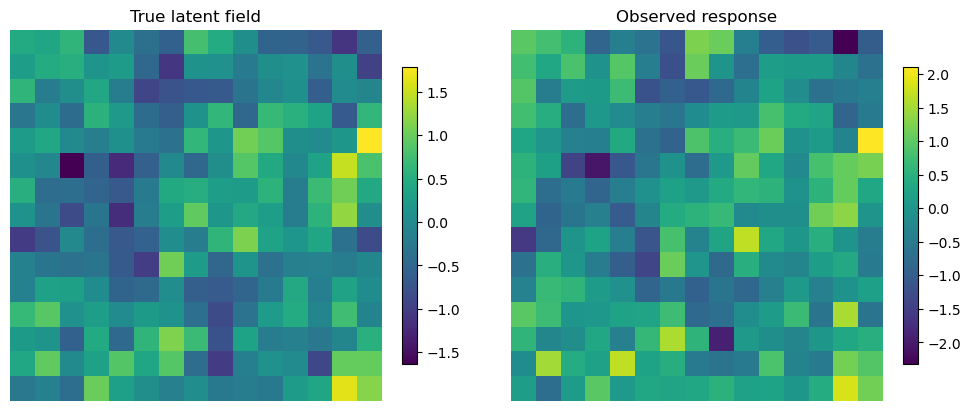

In [27]:
rng = np.random.default_rng(SEED)

F_true = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_true
    )
)

phi_true = (
    U_true
    @ (
        np.sqrt(F_true)
        * rng.normal(size=N)
    )
)

eta_true = BETA_TRUE + phi_true

y = (
    eta_true
    + rng.normal(
        loc=0.0,
        scale=np.sqrt(SIGMA2_TRUE),
        size=N,
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
)

image_0 = axes[0].imshow(
    eta_true.reshape(N_ROWS, N_COLS)
)
axes[0].set_title("True latent field")
axes[0].axis("off")
fig.colorbar(image_0, ax=axes[0], shrink=0.8)

image_1 = axes[1].imshow(
    y.reshape(N_ROWS, N_COLS)
)
axes[1].set_title("Observed response")
axes[1].axis("off")
fig.colorbar(image_1, ax=axes[1], shrink=0.8)

plt.show()

## 5. Create the holdout block and PyTorch tensors

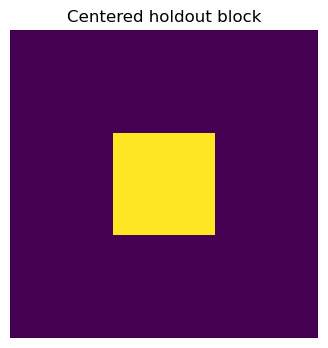

Training nodes: 200
Held-out nodes: 25


In [28]:
def centered_block_mask(side):
    """Return a centered square holdout mask."""
    mask = np.zeros(
        (N_ROWS, N_COLS),
        dtype=bool,
    )

    row_start = (N_ROWS - side) // 2
    col_start = (N_COLS - side) // 2

    mask[
        row_start:row_start + side,
        col_start:col_start + side,
    ] = True

    return mask.ravel()


def graph_tensors(lam, U):
    """Convert a graph eigendecomposition to PyTorch tensors."""
    lam_t = torch.tensor(
        np.clip(lam, 0.0, None),
        dtype=torch.double,
        device=DEVICE,
    )

    U_t = torch.tensor(
        U,
        dtype=torch.double,
        device=DEVICE,
    )

    return lam_t, U_t


test_mask = centered_block_mask(HOLDOUT_SIDE)
train_mask = ~test_mask

X_t = torch.ones(
    (N, 1),
    dtype=torch.double,
    device=DEVICE,
)

y_all_t = torch.tensor(
    y,
    dtype=torch.double,
    device=DEVICE,
)

is_holdout_t = torch.tensor(
    test_mask,
    dtype=torch.bool,
    device=DEVICE,
)

y_test_t = y_all_t[is_holdout_t].clone()

y_fit_t = y_all_t.clone()
y_fit_t[is_holdout_t] = torch.nan

prior_V0 = (
    10.0
    * torch.eye(
        1,
        dtype=torch.double,
        device=DEVICE,
    )
)

lam_true_t, U_true_t = graph_tensors(
    lam_true,
    U_true,
)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(test_mask.reshape(N_ROWS, N_COLS))
ax.set_title("Centered holdout block")
ax.axis("off")
plt.show()

print("Training nodes:", int(train_mask.sum()))
print("Held-out nodes:", int(test_mask.sum()))

## 6. Filter factories

In [29]:
def rho_to_raw(rho, rho_eps=1e-4):
    """Invert rho = (1-rho_eps) * sigmoid(rho_raw)."""
    probability = rho / (1.0 - rho_eps)

    if not 0.0 < probability < 1.0:
        raise ValueError(
            "rho is incompatible with rho_eps."
        )

    return math.log(
        probability
        / (1.0 - probability)
    )


def make_leroux_filter():
    """Correctly specified Leroux filter."""
    return LerouxCARFilterFullVI(
        mu_log_tau2=math.log(TAU2_TRUE),
        log_std_log_tau2=-2.3,
        mu_rho_raw=rho_to_raw(RHO_TRUE),
        log_std_rho_raw=-2.3,
        fixed_rho=None,
        rho_eps=1e-4,
    ).to(DEVICE)


def make_precision_spline_filter(lam_t):
    """Positive precision P-spline with generic initialization."""
    return PositivePrecisionPSplineFullVI(
        lam_max=float(lam_t.max().item()),
        mu_log_q_left=math.log(INIT_Q_LEFT),
        mu_log_q_right=math.log(INIT_Q_RIGHT),
        **PRECISION_SPLINE_KWARGS,
    ).to(DEVICE)

### Affine-Precision Nesting Check

For a Leroux spectrum,

$$
q(\lambda)=

\frac{1}{F(\lambda)}=

\frac{1-\rho}{\tau^2}
+
\frac{\rho}{\tau^2}\lambda,
$$

so the precision is affine in $\lambda$. With zero second differences, the precision P-spline should reproduce this spectrum up to floating-point error.

This is only a unit test; the fitted model itself uses the generic initialization described above.


In [30]:
q_left_true = (
    (1.0 - RHO_TRUE)
    / TAU2_TRUE
)

q_right_true = (
    (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * float(
            lam_true_t.max().item()
        )
    )
    / TAU2_TRUE
)

precision_spline_test = (
    PositivePrecisionPSplineFullVI(
        lam_max=float(
            lam_true_t.max().item()
        ),
        degree=3,
        n_internal_knots=5,
        prior_std_log_q=2.0,
        prior_std_d2=0.15,
        mu_log_q_left=math.log(q_left_true),
        mu_log_q_right=math.log(q_right_true),
        init_d2=0.0,
    )
    .to(DEVICE)
)

with torch.no_grad():
    F_nesting_test = (
        precision_spline_test.spectrum(
            lam_true_t,
            precision_spline_test.mean_unconstrained(),
        )
        .cpu()
        .numpy()
    )

maximum_nesting_error = float(
    np.max(
        np.abs(
            F_nesting_test - F_true
        )
    )
)

print(
    "Maximum affine-precision nesting error:",
    maximum_nesting_error,
)

Maximum affine-precision nesting error: 3.552713678800501e-15


## 7. VI fitting helper

In [31]:
def fit_spectral_model(
    *,
    label,
    lam_t,
    U_t,
    filter_module,
    iterations,
    learning_rate,
    seed,
):
    """Fit one spectral CAR model and predict the holdout block."""
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = SpectralCAR_HoldoutVI(
        X=X_t,
        y=y_fit_t,
        lam=lam_t,
        U=U_t,
        filter_module=filter_module,
        is_holdout=is_holdout_t,
        prior_m0=None,
        prior_V0=prior_V0,
        mu_log_sigma2=math.log(SIGMA2_TRUE),
        log_std_log_sigma2=-2.3,
        num_mc=NUM_MC,
        fixed_sigma2=(
            SIGMA2_TRUE
            if FIX_SIGMA2
            else None
        ),
        jitter=1e-8,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
    )

    history = []

    for iteration in range(iterations):
        optimizer.zero_grad()

        elbo, _ = model.elbo()
        loss = -elbo

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"{label}: non-finite loss "
                f"at iteration {iteration + 1}"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP,
        )

        optimizer.step()

        history.append(
            float(elbo.detach().cpu())
        )

        if (iteration + 1) % 250 == 0:
            recent_elbo = float(
                np.mean(history[-50:])
            )

            print(
                f"{label}: "
                f"{iteration + 1}/{iterations}, "
                f"ELBO={history[-1]:.3f}, "
                f"recent={recent_elbo:.3f}"
            )

    # Separate reproducible Monte Carlo stream for prediction.
    torch.manual_seed(seed + 10_000)

    prediction = model.predict_vi_mc(
        num_mc=PRED_MC,
    )

    metrics = model.score_predictions(
        y_test=y_test_t,
        prediction=prediction,
    )

    return {
        "label": label,
        "model": model,
        "prediction": prediction,
        "metrics": metrics,
        "history": history,
        "lam_t": lam_t,
    }

## 8. Fit the two correct-\(W\) models

In [32]:
correct_w_leroux = fit_spectral_model(
    label="Correct-W Leroux",
    lam_t=lam_true_t,
    U_t=U_true_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
    seed=SEED,
)

correct_w_precision_spline = fit_spectral_model(
    label="Correct-W precision P-spline",
    lam_t=lam_true_t,
    U_t=U_true_t,
    filter_module=make_precision_spline_filter(
        lam_true_t
    ),
    iterations=PRECISION_SPLINE_ITERS,
    learning_rate=PRECISION_SPLINE_LR,
    seed=SEED,
)

Correct-W Leroux: 250/1500, ELBO=-21.000, recent=-20.948
Correct-W Leroux: 500/1500, ELBO=-20.015, recent=-20.433
Correct-W Leroux: 750/1500, ELBO=-20.116, recent=-20.581
Correct-W Leroux: 1000/1500, ELBO=-20.391, recent=-20.426
Correct-W Leroux: 1250/1500, ELBO=-21.242, recent=-20.557
Correct-W Leroux: 1500/1500, ELBO=-20.539, recent=-20.439
Correct-W precision P-spline: 250/4000, ELBO=-25.139, recent=-25.767
Correct-W precision P-spline: 500/4000, ELBO=-26.635, recent=-24.980
Correct-W precision P-spline: 750/4000, ELBO=-23.895, recent=-24.518
Correct-W precision P-spline: 1000/4000, ELBO=-23.969, recent=-24.249
Correct-W precision P-spline: 1250/4000, ELBO=-25.378, recent=-24.253
Correct-W precision P-spline: 1500/4000, ELBO=-24.948, recent=-24.266
Correct-W precision P-spline: 1750/4000, ELBO=-23.883, recent=-24.015
Correct-W precision P-spline: 2000/4000, ELBO=-23.427, recent=-23.666
Correct-W precision P-spline: 2250/4000, ELBO=-23.703, recent=-23.593
Correct-W precision P-spline

## 9. Predictive comparison

In [33]:
def summarize_prediction(result):
    """Return noisy-response and latent-field holdout metrics."""
    pred_mean = (
        result["prediction"]["mean"]
        .detach()
        .cpu()
        .numpy()
    )

    eta_rmse = float(
        np.sqrt(
            np.mean(
                (
                    pred_mean
                    - eta_true[test_mask]
                ) ** 2
            )
        )
    )

    return {
        "model": result["label"],
        "test_y_rmse": float(
            result["metrics"]["rmse"]
        ),
        "test_y_mae": float(
            result["metrics"]["mae"]
        ),
        "test_eta_rmse": eta_rmse,
    }


prediction_results = pd.DataFrame(
    [
        summarize_prediction(
            correct_w_leroux
        ),
        summarize_prediction(
            correct_w_precision_spline
        ),
    ]
)

display(prediction_results)

leroux_eta_rmse = prediction_results.loc[
    prediction_results["model"]
    == "Correct-W Leroux",
    "test_eta_rmse",
].iloc[0]

spline_eta_rmse = prediction_results.loc[
    prediction_results["model"]
    == "Correct-W precision P-spline",
    "test_eta_rmse",
].iloc[0]

relative_eta_difference = (
    spline_eta_rmse - leroux_eta_rmse
) / leroux_eta_rmse

print(
    "Relative precision-spline eta-RMSE difference:",
    relative_eta_difference,
)

,model,test_y_rmse,test_y_mae,test_eta_rmse
0,Correct-W Leroux,0.704957,0.570036,0.583939
1,Correct-W precision P-spline,0.717237,0.580624,0.602608


Relative precision-spline eta-RMSE difference: 0.03197178753130998


## 10. Spectral recovery

In [35]:
@torch.no_grad()
def plugin_spectrum(result):
    """Evaluate the spectrum at the variational mean parameters."""
    model = result["model"]

    return (
        model.filter.spectrum(
            result["lam_t"],
            model.filter.mean_unconstrained(),
        )
        .detach()
        .cpu()
        .numpy()
    )

@torch.no_grad()
def posterior_spectrum_summary(
    result,
    draws=512,
    credible_level=0.95,
    seed=10_000,
):
    """
    Monte Carlo summaries of the variational posterior spectrum.

    Returns
    -------
    mean : np.ndarray
        Pointwise posterior mean E_q[F(lambda)].
    lower : np.ndarray
        Pointwise lower credible bound.
    upper : np.ndarray
        Pointwise upper credible bound.
    """
    if not 0.0 < credible_level < 1.0:
        raise ValueError("credible_level must lie between 0 and 1.")

    torch.manual_seed(seed)

    model = result["model"]
    spectra = []

    for _ in range(draws):
        theta = model.filter.sample_unconstrained()

        spectra.append(
            model.filter.spectrum(
                result["lam_t"],
                theta,
            )
        )

    spectra = torch.stack(spectra, dim=0)

    tail_probability = (1.0 - credible_level) / 2.0

    mean = spectra.mean(dim=0)
    lower = torch.quantile(
        spectra,
        tail_probability,
        dim=0,
    )
    upper = torch.quantile(
        spectra,
        1.0 - tail_probability,
        dim=0,
    )

    return tuple(
        value.detach().cpu().numpy()
        for value in (mean, lower, upper)
    )



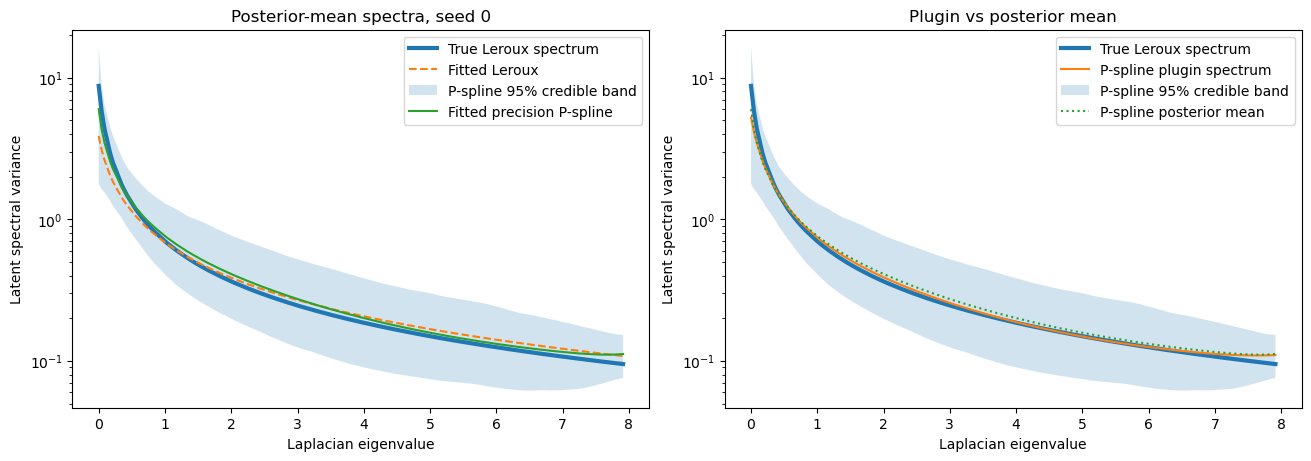

In [36]:
F_leroux_plugin = plugin_spectrum(
    correct_w_leroux
)

F_spline_plugin = plugin_spectrum(
    correct_w_precision_spline
)

(
    F_leroux_posterior_mean,
    _,
    _,
) = posterior_spectrum_summary(
    correct_w_leroux,
    draws=512,
    credible_level=0.95,
    seed=10_001,
)

(
    F_spline_posterior_mean,
    F_spline_posterior_lower,
    F_spline_posterior_upper,
) = posterior_spectrum_summary(
    correct_w_precision_spline,
    draws=512,
    credible_level=0.95,
    seed=10_002,
)

order = np.argsort(lam_true)

lam_plot = lam_true[order]
F_true_plot = F_true[order]

F_leroux_mean_plot = (
    F_leroux_posterior_mean[order]
)

F_spline_plugin_plot = (
    F_spline_plugin[order]
)

F_spline_mean_plot = (
    F_spline_posterior_mean[order]
)

F_spline_lower_plot = (
    F_spline_posterior_lower[order]
)

F_spline_upper_plot = (
    F_spline_posterior_upper[order]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
    constrained_layout=True,
)

# Posterior-mean comparison
axes[0].plot(
    lam_plot,
    F_true_plot,
    linewidth=3,
    label="True Leroux spectrum",
)

axes[0].plot(
    lam_plot,
    F_leroux_mean_plot,
    linestyle="--",
    label="Fitted Leroux",
)

axes[0].fill_between(
    lam_plot,
    F_spline_lower_plot,
    F_spline_upper_plot,
    alpha=0.2,
    label="P-spline 95% credible band",
)

axes[0].plot(
    lam_plot,
    F_spline_mean_plot,
    label="Fitted precision P-spline",
)

axes[0].set_yscale("log")
axes[0].set_xlabel("Laplacian eigenvalue")
axes[0].set_ylabel("Latent spectral variance")
axes[0].set_title(
    f"Posterior-mean spectra, seed {SEED}"
)
axes[0].legend()


# Plugin versus posterior mean
axes[1].plot(
    lam_plot,
    F_true_plot,
    linewidth=3,
    label="True Leroux spectrum",
)

axes[1].plot(
    lam_plot,
    F_spline_plugin_plot,
    label="P-spline plugin spectrum",
)

axes[1].fill_between(
    lam_plot,
    F_spline_lower_plot,
    F_spline_upper_plot,
    alpha=0.2,
    label="P-spline 95% credible band",
)

axes[1].plot(
    lam_plot,
    F_spline_mean_plot,
    linestyle=":",
    label="P-spline posterior mean",
)

axes[1].set_yscale("log")
axes[1].set_xlabel("Laplacian eigenvalue")
axes[1].set_ylabel("Latent spectral variance")
axes[1].set_title("Plugin vs posterior mean")
axes[1].legend()

plt.show()

In [37]:
def log_spectrum_rmse(
    estimated,
    target,
    mask=None,
):
    """RMSE between log spectra."""
    estimated = np.asarray(
        estimated,
        dtype=float,
    )

    target = np.asarray(
        target,
        dtype=float,
    )

    if mask is not None:
        estimated = estimated[mask]
        target = target[mask]

    estimated = np.clip(
        estimated,
        1e-12,
        None,
    )

    target = np.clip(
        target,
        1e-12,
        None,
    )

    return float(
        np.sqrt(
            np.mean(
                (
                    np.log(estimated)
                    - np.log(target)
                ) ** 2
            )
        )
    )


positive_mode_mask = lam_true > 1e-8

spectrum_results = pd.DataFrame(
    [
        {
            "model": "Correct-W Leroux",
            "log_spectrum_rmse_all": (
                log_spectrum_rmse(
                    F_leroux_posterior_mean,
                    F_true,
                )
            ),
            "log_spectrum_rmse_positive": (
                log_spectrum_rmse(
                    F_leroux_posterior_mean,
                    F_true,
                    positive_mode_mask,
                )
            ),
        },
        {
            "model": "Correct-W precision P-spline",
            "log_spectrum_rmse_all": (
                log_spectrum_rmse(
                    F_spline_posterior_mean,
                    F_true,
                )
            ),
            "log_spectrum_rmse_positive": (
                log_spectrum_rmse(
                    F_spline_posterior_mean,
                    F_true,
                    positive_mode_mask,
                )
            ),
        },
    ]
)

display(spectrum_results)

,model,log_spectrum_rmse_all,log_spectrum_rmse_positive
0,Correct-W Leroux,0.140470,0.129823
1,Correct-W precision P-spline,0.095149,0.091941


## 11. Precision-spline curvature diagnostic

Estimated left precision: 0.19105590923844248
Estimated right precision: 9.082083544400946
L2 norm of second differences: 0.08201413865975991
Maximum absolute second difference: 0.04899534757678138
Maximum absolute log-spectrum correction: 0.14614222726440887


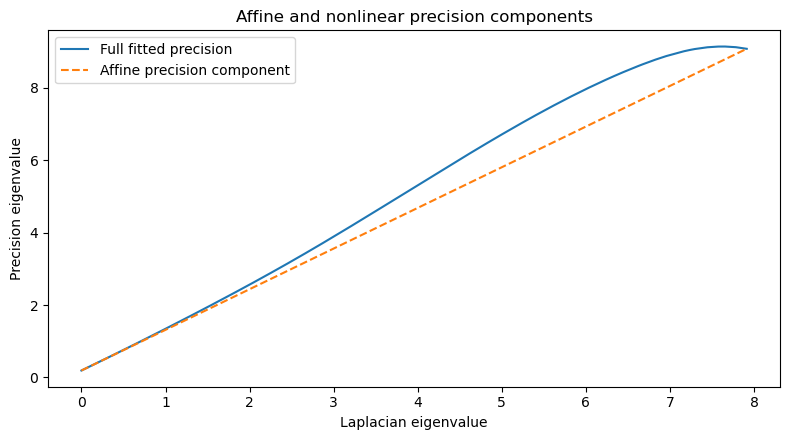

In [38]:
@torch.no_grad()
def precision_spline_diagnostics(result):
    """Extract affine and nonlinear precision components."""
    model = result["model"]
    theta_mean = (
        model.filter
        .mean_unconstrained()
    )

    q_full = (
        model.filter
        .precision_from_unconstrained(
            result["lam_t"],
            theta_mean,
        )
        .cpu()
        .numpy()
    )

    q_affine = (
        model.filter
        .affine_precision_from_unconstrained(
            result["lam_t"],
            theta_mean,
        )
        .cpu()
        .numpy()
    )

    correction = (
        model.filter
        .correction_from_unconstrained(
            result["lam_t"],
            theta_mean,
        )
        .cpu()
        .numpy()
    )

    return q_full, q_affine, correction


q_full, q_affine, log_spectrum_correction = (
    precision_spline_diagnostics(
        correct_w_precision_spline
    )
)

summary = (
    correct_w_precision_spline["model"]
    .filter
    .shrinkage_summary()
)

print(
    "Estimated left precision:",
    float(summary["q_left"].cpu()),
)
print(
    "Estimated right precision:",
    float(summary["q_right"].cpu()),
)
print(
    "L2 norm of second differences:",
    float(summary["d2_l2"].cpu()),
)
print(
    "Maximum absolute second difference:",
    float(summary["max_abs_d2"].cpu()),
)
print(
    "Maximum absolute log-spectrum correction:",
    float(
        np.max(
            np.abs(
                log_spectrum_correction[
                    positive_mode_mask
                ]
            )
        )
    ),
)

order = np.argsort(lam_true)

plt.figure(figsize=(8, 4.5))

plt.plot(
    lam_true[order],
    q_full[order],
    label="Full fitted precision",
)
plt.plot(
    lam_true[order],
    q_affine[order],
    linestyle="--",
    label="Affine precision component",
)

plt.xlabel("Laplacian eigenvalue")
plt.ylabel("Precision eigenvalue")
plt.title("Affine and nonlinear precision components")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Optimization diagnostics

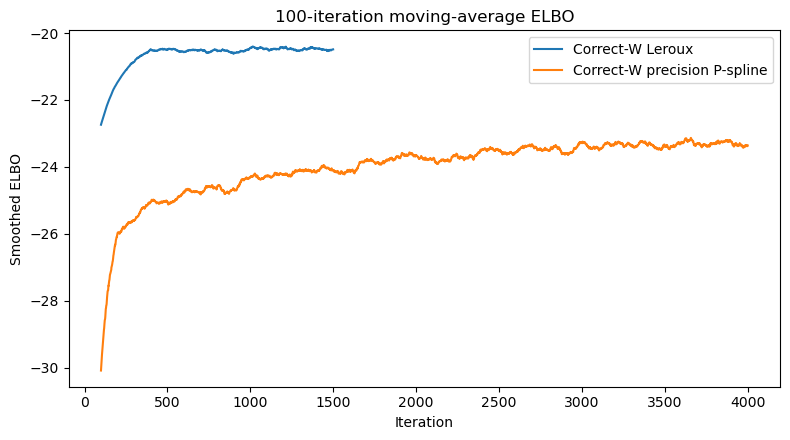

In [39]:
def plot_elbo_histories(
    results,
    window=100,
):
    """Plot smoothed ELBO histories for multiple fits."""
    plt.figure(figsize=(8, 4.5))

    for result in results:
        history = np.asarray(
            result["history"]
        )

        smoothed = (
            pd.Series(history)
            .rolling(window)
            .mean()
        )

        plt.plot(
            smoothed,
            label=result["label"],
        )

    plt.xlabel("Iteration")
    plt.ylabel("Smoothed ELBO")
    plt.title(
        f"{window}-iteration moving-average ELBO"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_elbo_histories(
    [
        correct_w_leroux,
        correct_w_precision_spline,
    ]
)

## Interpretation

This calibration succeeds when:

1. the precision P-spline has holdout RMSE comparable to correct-\(W\) Leroux;
2. its fitted covariance spectrum is close to the true Leroux spectrum;
3. its estimated precision remains close to affine, so the second-difference correction is modest;
4. both ELBO histories appear stable.

After this baseline is validated across several seeds, the next notebook stage should keep the spline configuration fixed and replace \(W_{\mathrm{true}}\) in the fitted models with controlled perturbed versions \(W_\delta\).